# Setup

In [43]:
#Imports
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

from pathlib import Path
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchaudio
import torchaudio.transforms as T

import librosa

### Making sure import works

In [45]:
from pathlib import Path

#hugging face didn't work, had to download and move manually
DATA_DIR = Path("Data/genres_original")

#just two genres
GENRES = ["classical", "metal"]

filepaths = []
labels = []

label_map = {genre: i for i, genre in enumerate(GENRES)}
inv_label_map = {i: genre for genre, i in label_map.items()}

for genre in GENRES:
    genre_dir = DATA_DIR / genre
    print(genre_dir)
    for wav_file in genre_dir.glob("*.wav"):
        filepaths.append(str(wav_file))
        labels.append(label_map[genre])

print("Total files found:", len(filepaths))
print("Label map:", label_map)
print("First 5 files:", filepaths[:5])

Data\genres_original\classical
Data\genres_original\metal
Total files found: 200
Label map: {'classical': 0, 'metal': 1}
First 5 files: ['Data\\genres_original\\classical\\classical.00000.wav', 'Data\\genres_original\\classical\\classical.00001.wav', 'Data\\genres_original\\classical\\classical.00002.wav', 'Data\\genres_original\\classical\\classical.00003.wav', 'Data\\genres_original\\classical\\classical.00004.wav']


In [46]:
#Setup to be able to reproduce
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# Configuration (re-import now that I know it works)

In [48]:
# Data paths
DATA_DIR = Path("Data/genres_original")
GENRES = ["classical", "metal"]   # keep it to 2 for speed

# Audio / spectrogram settings
SAMPLE_RATE = 22050
SEGMENT_SECONDS = 5                          # was 3
SEGMENT_LENGTH = SAMPLE_RATE * SEGMENT_SECONDS

N_FFT = 1024
HOP_LENGTH = 256
N_MELS = 80                                  # was 64, matches HiFi-GAN

BATCH_SIZE = 8                               # was 16, reduced for larger input
LATENT_DIM = 128                             # was 32
EPOCHS = 30                                  # was 15
LEARNING_RATE = 1e-3

# Outputs
OUT_IMG = Path("outputs/images")
OUT_AUDIO = Path("outputs/audio")
OUT_IMG.mkdir(parents=True, exist_ok=True)
OUT_AUDIO.mkdir(parents=True, exist_ok=True)

# Get paths

In [50]:
filepaths = []
labels = []

label_map = {genre: i for i, genre in enumerate(GENRES)}
inv_label_map = {i: genre for genre, i in label_map.items()}

for genre in GENRES:
    genre_dir = DATA_DIR / genre
    for wav_file in genre_dir.glob("*.wav"):
        filepaths.append(str(wav_file))
        labels.append(label_map[genre])

print("Total files:", len(filepaths))
print("Label map:", label_map)

Total files: 200
Label map: {'classical': 0, 'metal': 1}


# Train/Validation Split

In [52]:
train_files, val_files, train_labels, val_labels = train_test_split(
    filepaths, labels, test_size=0.2, random_state=SEED, stratify=labels
)

print("Train:", len(train_files), "Validation:", len(val_files))

Train: 160 Validation: 40


# Data Conversion

Splitting and transforming segements into spectograms

In [54]:
#class with methods to transform


class GTZANMelDataset(Dataset):
    def __init__(self, file_list, label_list, sample_rate=22050, segment_length=66150,
                 n_fft=1024, hop_length=256, n_mels=64, segments_per_file=3):
        self.file_list = file_list
        self.label_list = label_list
        self.sample_rate = sample_rate
        self.segment_length = segment_length
        self.segments_per_file = segments_per_file
        
        self.mel_transform = T.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels
        )
        
        self.items = []
        for fp, lbl in zip(file_list, label_list):
            for _ in range(segments_per_file):
                self.items.append((fp, lbl))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        fp, lbl = self.items[idx]
    
        # Load audio with librosa instead of torchaudio
        waveform, sr = librosa.load(fp, sr=self.sample_rate, mono=True)
        waveform = torch.tensor(waveform, dtype=torch.float32)
    
        # Random 3-second crop
        if waveform.shape[0] < self.segment_length:
            pad_amount = self.segment_length - waveform.shape[0]
            waveform = F.pad(waveform, (0, pad_amount))
        else:
            start = random.randint(0, waveform.shape[0] - self.segment_length)
            waveform = waveform[start:start + self.segment_length]
    
        # Mel spectrogram
        mel = self.mel_transform(waveform)  # [n_mels, time]
        mel = torch.log(mel + 1e-6)
    
        # Normalize per sample — save stats so we can invert later
        mel_mean = mel.mean()
        mel_std  = mel.std() + 1e-6
        mel = (mel - mel_mean) / mel_std
    
        # Add channel dimension for CNN
        mel = mel.unsqueeze(0)  # [1, n_mels, time]
    
        return mel, torch.tensor(lbl, dtype=torch.long), mel_mean, mel_std

In [55]:
#using classes and methods to tranform

train_dataset = GTZANMelDataset(train_files, train_labels, sample_rate=SAMPLE_RATE,
                                segment_length=SEGMENT_LENGTH, n_fft=N_FFT,
                                hop_length=HOP_LENGTH, n_mels=N_MELS,
                                segments_per_file=3)

val_dataset = GTZANMelDataset(val_files, val_labels, sample_rate=SAMPLE_RATE,
                              segment_length=SEGMENT_LENGTH, n_fft=N_FFT,
                              hop_length=HOP_LENGTH, n_mels=N_MELS,
                              segments_per_file=2)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

sample_x, sample_y, _, __ = next(iter(train_loader))
print("Sample batch shape:", sample_x.shape)
print("Sample labels shape:", sample_y.shape)

Sample batch shape: torch.Size([8, 1, 80, 431])
Sample labels shape: torch.Size([8])


## Show/visual of one example

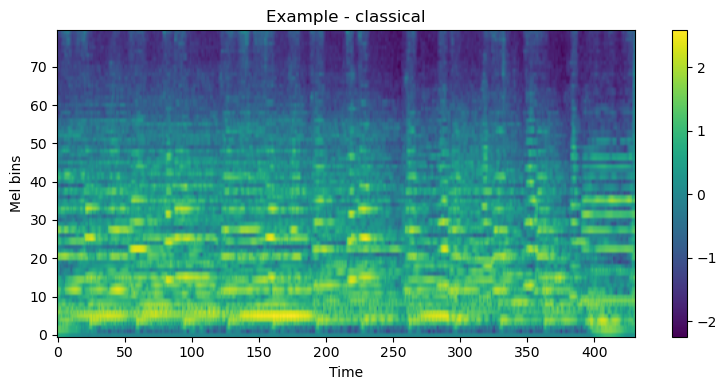

In [57]:
def show_mel(mel_tensor, title="Mel Spectrogram"):
    mel = mel_tensor.squeeze().cpu().numpy()
    plt.figure(figsize=(8, 4))
    plt.imshow(mel, origin="lower", aspect="auto")
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Mel bins")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

show_mel(sample_x[0], title=f"Example - {inv_label_map[sample_y[0].item()]}")

# Build and intialize VAE + setup

after building and initializing, adds loss function and optimizer

In [72]:
class CVAE(nn.Module):
    def __init__(self, input_shape=(1, 64, 259), latent_dim=32, num_classes=2, label_embed_dim=8):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.label_embed_dim = label_embed_dim
        self.input_shape = input_shape
        
        self.label_emb = nn.Embedding(num_classes, label_embed_dim)

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1 + 1, 16, kernel_size=4, stride=2, padding=1),   # label map added as extra channel
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        )

        # Infer conv output size dynamically
        with torch.no_grad():
            dummy_x = torch.zeros(1, *input_shape)
            dummy_lbl = torch.zeros(1, dtype=torch.long)
            enc_out = self._encode_conv(dummy_x, dummy_lbl)
            self.flatten_dim = enc_out.view(1, -1).shape[1]
            self.enc_shape = enc_out.shape[1:]  # save (64, H, W)

        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # Decoder
        self.fc_decode = nn.Linear(latent_dim + label_embed_dim, self.flatten_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, output_padding=(0, 1)),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
        )

    def _make_label_map(self, labels, h, w):
        emb = self.label_emb(labels)                     # [B, embed_dim]
        emb = emb.mean(dim=1, keepdim=True)             # [B, 1]
        emb_map = emb.unsqueeze(-1).unsqueeze(-1)       # [B, 1, 1, 1]
        emb_map = emb_map.expand(-1, 1, h, w)           # [B, 1, H, W]
        return emb_map

    def _encode_conv(self, x, labels):
        b, c, h, w = x.shape
        label_map = self._make_label_map(labels, h, w)
        x = torch.cat([x, label_map], dim=1)
        return self.encoder(x)

    def encode(self, x, labels):
        h = self._encode_conv(x, labels)
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, labels):
        label_vec = self.label_emb(labels)
        z = torch.cat([z, label_vec], dim=1)
        h = self.fc_decode(z)
        h = h.view(h.size(0), *self.enc_shape)  # dynamic reshape
        x_hat = self.decoder(h)
        return x_hat

    def forward(self, x, labels):
        mu, logvar = self.encode(x, labels)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z, labels)
        x_hat = F.interpolate(x_hat, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return x_hat, mu, logvar

In [74]:
sample_input, _, __, ___ = next(iter(train_loader))
input_shape = tuple(sample_input.shape[1:])  # [C, H, W]

model = CVAE(input_shape=input_shape, latent_dim=LATENT_DIM, num_classes=len(GENRES)).to(device)
print(model)

CVAE(
  (label_emb): Embedding(2, 8)
  (encoder): Sequential(
    (0): Conv2d(2, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (fc_mu): Linear(in_features=33920, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=33920, out_features=128, bias=True)
  (fc_decode): Linear(in_features=136, out_features=33920, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), output_padding=(0, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  )
)


In [76]:
#loss function
def vae_loss(recon_x, x, mu, logvar, beta=0.0001):   # was 0.001
    recon_loss = F.mse_loss(recon_x, x, reduction='sum') / x.size(0)  # was 'mean'
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Main Training Loop

In [79]:
#training loop
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0

    for x, y, _, __ in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss, recon_loss, kl_loss = vae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for x, y, _, __ in val_loader:
            x, y = x.to(device), y.to(device)
            recon_x, mu, logvar = model(x, y)
            loss, _, _ = vae_loss(recon_x, x, mu, logvar)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

Epoch [1/30] - Train Loss: 15598.1031 - Val Loss: 11109.0491
Epoch [2/30] - Train Loss: 9233.5418 - Val Loss: 9519.7178
Epoch [3/30] - Train Loss: 8708.9102 - Val Loss: 9154.6394
Epoch [4/30] - Train Loss: 8358.6874 - Val Loss: 8652.5995
Epoch [5/30] - Train Loss: 8039.4364 - Val Loss: 8606.3658
Epoch [6/30] - Train Loss: 7961.9042 - Val Loss: 8575.7392
Epoch [7/30] - Train Loss: 7885.4288 - Val Loss: 8177.0261
Epoch [8/30] - Train Loss: 7478.2314 - Val Loss: 7962.4702
Epoch [9/30] - Train Loss: 7417.2228 - Val Loss: 8302.2465
Epoch [10/30] - Train Loss: 7163.6110 - Val Loss: 8103.1677
Epoch [11/30] - Train Loss: 7233.4289 - Val Loss: 7778.7979
Epoch [12/30] - Train Loss: 6977.2145 - Val Loss: 7424.2199
Epoch [13/30] - Train Loss: 6828.9252 - Val Loss: 7629.8167
Epoch [14/30] - Train Loss: 6858.1902 - Val Loss: 7559.4748
Epoch [15/30] - Train Loss: 6633.8892 - Val Loss: 7178.4625
Epoch [16/30] - Train Loss: 6662.2701 - Val Loss: 6837.4157
Epoch [17/30] - Train Loss: 6421.8519 - Val Los

# Model evaluation 

- Plot training curves
- reconstruction and genre transfer
- visualize original, reconstruction, and transferred output

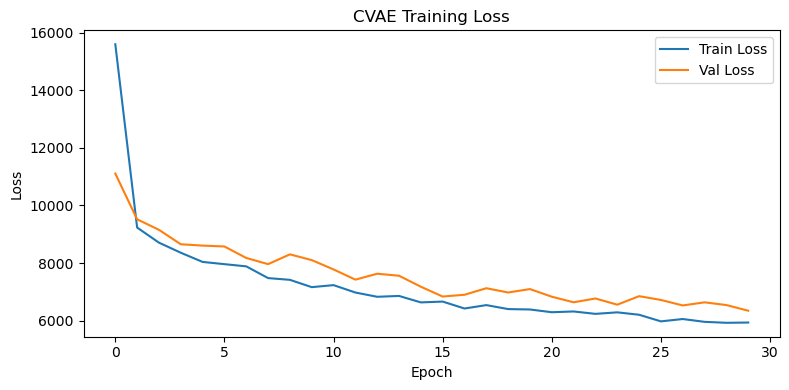

In [81]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("CVAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_IMG / "training_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [82]:
model.eval()

x_batch, y_batch, mean_batch, std_batch = next(iter(val_loader))


x_batch, y_batch = x_batch.to(device), y_batch.to(device)

idx = 0
x = x_batch[idx:idx+1]
source_label = y_batch[idx:idx+1]

target_label = torch.tensor([1 - source_label.item()], device=device)

with torch.no_grad():
    mu, logvar = model.encode(x, source_label)
    z = model.reparameterize(mu, logvar)

    recon_same = model.decode(z, source_label)
    transfer_out = model.decode(z, target_label)

    recon_same = F.interpolate(recon_same, size=x.shape[-2:], mode="bilinear", align_corners=False)
    transfer_out = F.interpolate(transfer_out, size=x.shape[-2:], mode="bilinear", align_corners=False)

print("Source genre:", inv_label_map[source_label.item()])
print("Target genre:", inv_label_map[target_label.item()])

Source genre: classical
Target genre: metal


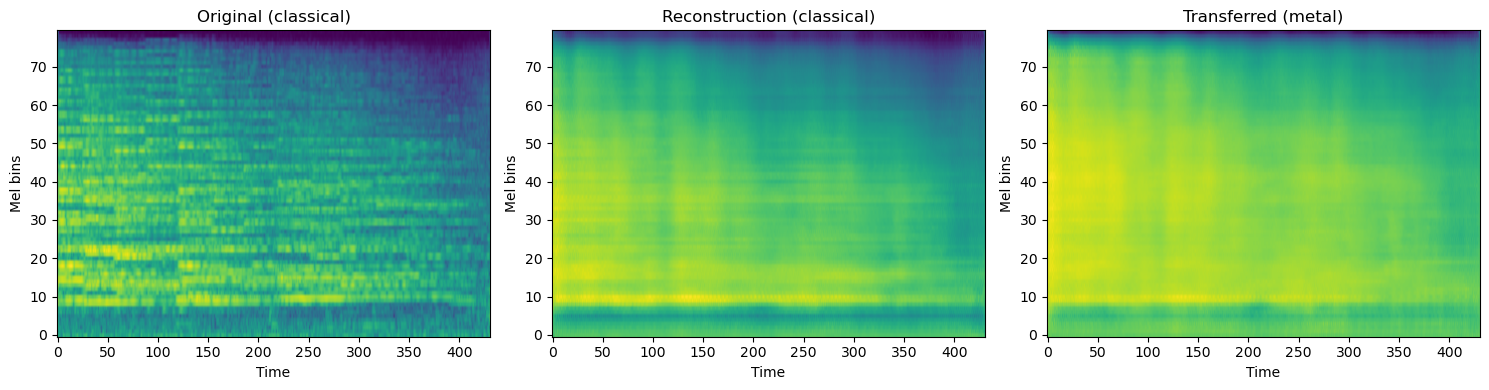

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

images = [
    x[0].squeeze().cpu().numpy(),
    recon_same[0].squeeze().cpu().numpy(),
    transfer_out[0].squeeze().cpu().numpy()
]

titles = [
    f"Original ({inv_label_map[source_label.item()]})",
    f"Reconstruction ({inv_label_map[source_label.item()]})",
    f"Transferred ({inv_label_map[target_label.item()]})"
]

for ax, img, title in zip(axes, images, titles):
    im = ax.imshow(img, origin="lower", aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Mel bins")

plt.tight_layout()
plt.savefig(OUT_IMG / "genre_transfer_example.png", dpi=300, bbox_inches="tight")
plt.show()

# Save model

In [85]:
torch.save(model.state_dict(), "cvae_music_transfer.pt")
print("Model saved.")

Model saved.


# Extra, actaully trying to extract audio 

In [87]:
from transformers import SpeechT5HifiGan
import torch

vocoder = SpeechT5HifiGan.from_pretrained("microsoft/speecht5_hifigan").to(device)
vocoder.eval()

def mel_to_audio(mel_tensor, mel_mean, mel_std, out_path):
    mel = mel_tensor.squeeze().cpu()         # [80, time]

    mel = mel * mel_std + mel_mean           # undo z-score
    mel = torch.exp(mel)                     # undo log
    mel = mel.clamp(min=1e-5)

    mel_input = mel.T.unsqueeze(0).to(device)  # [1, time, 80]

    with torch.no_grad():
        waveform = vocoder(mel_input)

    waveform = waveform.squeeze().cpu().numpy()
    waveform = waveform / (np.abs(waveform).max() + 1e-8)
    sf.write(out_path, waveform, SAMPLE_RATE)

C:\Users\benja\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [88]:
# Save audio outputs
orig_path = OUT_AUDIO / "original.wav"
recon_path = OUT_AUDIO / "reconstructed.wav"
transfer_path = OUT_AUDIO / "transferred.wav"


# grab stats for the one sample you're using
s_mean = mean_batch[idx].item()
s_std  = std_batch[idx].item()

mel_to_audio(x[0], s_mean, s_std, orig_path)
mel_to_audio(recon_same[0], s_mean, s_std, recon_path)
mel_to_audio(transfer_out[0], s_mean, s_std, transfer_path)

print("Saved:")
print(orig_path)
print(recon_path)
print(transfer_path)

Saved:
outputs\audio\original.wav
outputs\audio\reconstructed.wav
outputs\audio\transferred.wav


In [89]:
from IPython.display import Audio, display

# save the actual original audio for comparison
source_fp = val_files[idx]
waveform_orig, _ = librosa.load(source_fp, sr=SAMPLE_RATE, mono=True)
waveform_orig = waveform_orig[:SEGMENT_LENGTH]
sf.write(OUT_AUDIO / "true_original.wav", waveform_orig, SAMPLE_RATE)

display(Audio("outputs/audio/true_original.wav"))
display(Audio("outputs/audio/original.wav"))
display(Audio("outputs/audio/reconstructed.wav"))
display(Audio("outputs/audio/transferred.wav"))